In [1]:
# Importa la clase 'files' del módulo 'google.colab', que permite interactuar con el sistema de archivos de Colab.
from google.colab import files

# Llama al método 'upload()' para abrir un widget que permite al usuario seleccionar y subir archivos desde su máquina local a la sesión de Colab.
# Los archivos subidos se almacenan en la variable 'archivos' como un diccionario, donde las claves son los nombres de los archivos y los valores son sus contenidos en bytes.
archivos = files.upload()

# Objetivo del código: Permitir al usuario subir archivos desde su computadora local al entorno de Google Colab.

Saving train.csv to train.csv


In [2]:
# Importa la librería pandas, comúnmente utilizada para manipulación y análisis de datos.
import pandas as pd

# Carga el archivo CSV llamado 'train.csv' en un DataFrame de pandas.
# Este DataFrame contendrá los datos del conjunto de entrenamiento.
data = pd.read_csv("train.csv")

# Muestra las primeras 5 filas del DataFrame 'data' para una inspección rápida de los datos.
display(data.head())
# Imprime la forma (número de filas y columnas) del DataFrame 'data'.
print(data.shape)

# Objetivo del código: Cargar un conjunto de datos desde un archivo CSV, mostrar sus primeras filas y su
#dimensión para una exploración inicial.

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


(1460, 81)


Filas: 1460
Columnas: 81


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


,variable,motivo
0,SalePrice,Objetivo
1,Id,Identificador
2,MoSold,Mes efectivo de venta
3,YrSold,Anio efectivo de venta
4,SaleType,Tipo final de venta
5,SaleCondition,Condicion final de venta


Predictores pre-venta: 75


,tipo,cantidad
0,Numericas,34
1,Categoricas,41
2,Total,75


Filas duplicadas: 0
Ids duplicados: 0


,n_nulos,pct_nulos,tipo,n_unicos
PoolQC,1453,99.52,object,3
MiscFeature,1406,96.30,object,4
Alley,1369,93.77,object,2
Fence,1179,80.75,object,4
MasVnrType,872,59.73,object,3
...,...,...,...,...
EnclosedPorch,0,0.00,int64,120
PoolArea,0,0.00,int64,8
ScreenPorch,0,0.00,int64,76
3SsnPorch,0,0.00,int64,20


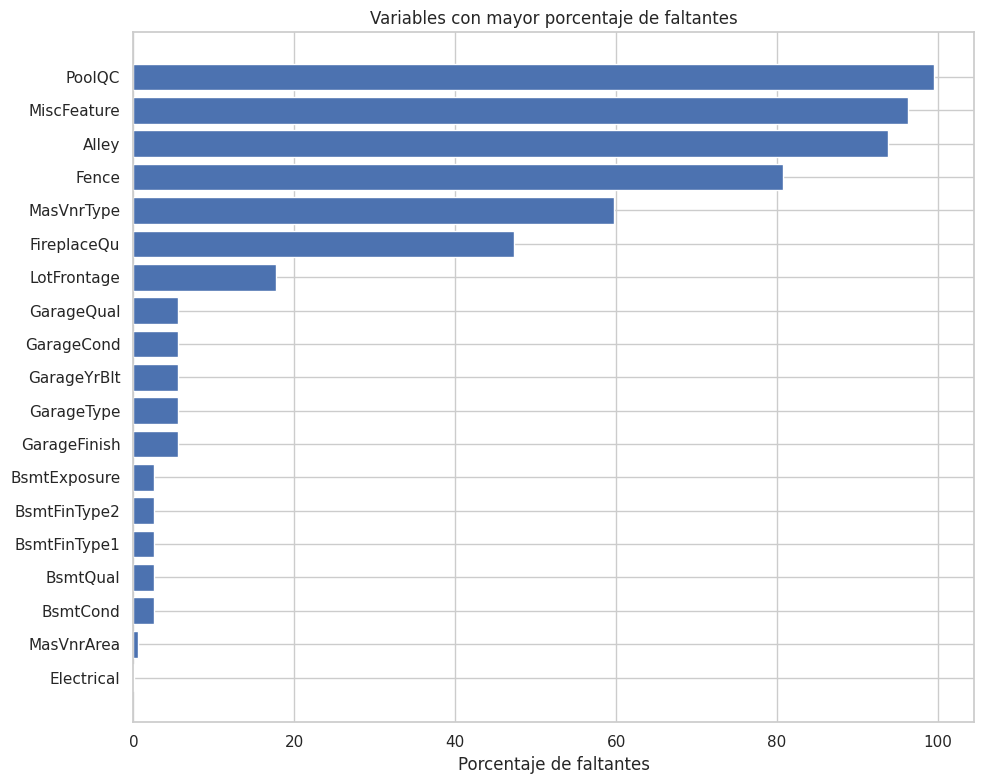

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64
Asimetria: 1.8828757597682129


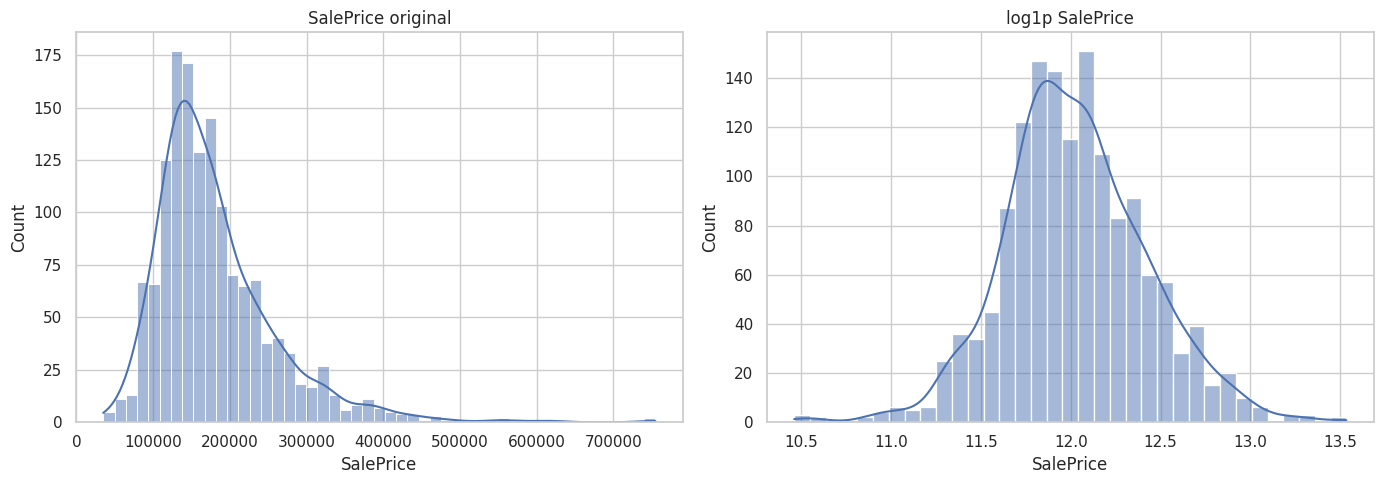

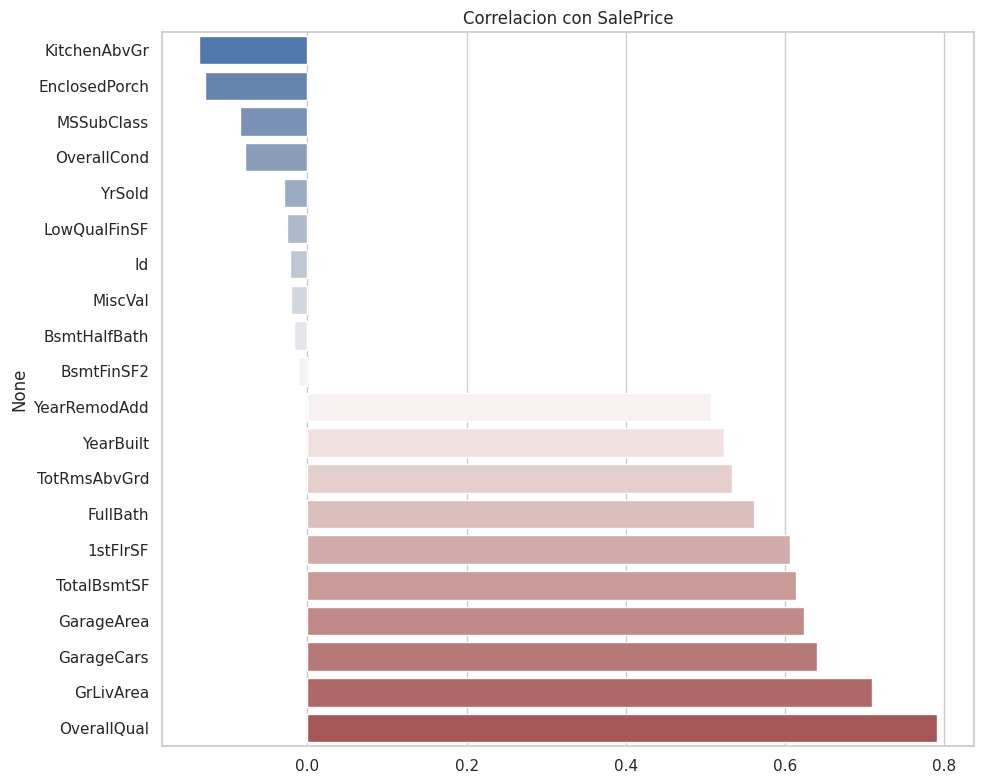

,split,filas,pct
0,train,1022,0.70
1,validacion,219,0.15
2,test,219,0.15


Preparacion completada.
Variables post-venta eliminadas: ['MoSold', 'YrSold', 'SaleType', 'SaleCondition']


In [3]:
# =========================================================
# PREPARACION DE DATOS PRE-VENTA
# Este bloque de código realiza la preparación de datos para un modelo de predicción de precios de venta,
# asegurándose de que solo se utilicen características disponibles antes de la venta.
# Usa el DataFrame existente: data = pd.read_csv('train.csv')
# =========================================================

# Importación de librerías necesarias para el procesamiento de datos, visualización y machine learning.
import warnings
import joblib # Para guardar y cargar objetos Python (e.g., pipelines).
import numpy as np # Para operaciones numéricas.
import pandas as pd # Para manipulación de DataFrames.
import matplotlib.pyplot as plt # Para la creación de gráficos estáticos.
import seaborn as sns # Para visualizaciones estadísticas atractivas.

from IPython.display import display # Para mostrar DataFrames de forma agradable en Jupyter/Colab.
from sklearn.base import BaseEstimator, TransformerMixin # Clases base para crear estimadores y transformadores personalizados.
from sklearn.compose import ColumnTransformer # Para aplicar diferentes transformaciones a diferentes columnas.
from sklearn.feature_selection import VarianceThreshold # Para eliminar características con baja varianza (constantes).
from sklearn.impute import SimpleImputer # Para manejar valores faltantes.
from sklearn.model_selection import train_test_split # Para dividir los datos en conjuntos de entrenamiento, validación y prueba.
from sklearn.pipeline import Pipeline # Para encadenar múltiples pasos de procesamiento.
from sklearn.preprocessing import OneHotEncoder, RobustScaler # Para codificación de variables categóricas y escalado de numéricas.

warnings.filterwarnings('ignore') # Ignora advertencias para una salida más limpia.
sns.set_theme(style='whitegrid') # Establece el estilo de los gráficos de Seaborn.
RANDOM_STATE = 42 # Semilla para la reproducibilidad de resultados aleatorios.
np.random.seed(RANDOM_STATE) # Establece la semilla para NumPy.

# ---------------------------------------------------------
# 1. DATAFRAME YA CARGADO
# Esta sección inicializa el DataFrame y realiza validaciones básicas.
# ---------------------------------------------------------
assert 'data' in globals() # Asegura que el DataFrame 'data' ya haya sido cargado en el entorno global.

df_raw = data.copy() # Crea una copia del DataFrame original para no modificar los datos iniciales.
df_raw = df_raw.replace('NA', np.nan) # Reemplaza los valores 'NA' (texto) por NaN (Not a Number) para el manejo de faltantes.

TARGET = 'SalePrice' # Define la variable objetivo a predecir.
ID_COL = 'Id' # Define la columna de identificación única.

# Validaciones para asegurar la presencia y calidad de las columnas clave.
assert TARGET in df_raw.columns # Asegura que la columna objetivo exista.
assert ID_COL in df_raw.columns # Asegura que la columna de ID exista.
assert df_raw[TARGET].notna().all() # Asegura que no haya valores nulos en la columna objetivo.
assert df_raw[ID_COL].is_unique # Asegura que la columna de ID tenga valores únicos.
assert (df_raw[TARGET] > 0).all() # Asegura que todos los precios de venta sean positivos.

print('Filas:', df_raw.shape[0]) # Imprime el número de filas del DataFrame.
print('Columnas:', df_raw.shape[1]) # Imprime el número de columnas del DataFrame.
display(df_raw.head()) # Muestra las primeras filas del DataFrame para una inspección rápida.

# ---------------------------------------------------------
# 2. ELIMINAR VARIABLES POST-VENTA
# Se identifican y eliminan variables que no estarían disponibles antes de la venta.
# ---------------------------------------------------------
POST_SALE_COLS = [ # Lista de columnas que representan información posterior a la venta.
    'MoSold',
    'YrSold',
    'SaleType',
    'SaleCondition'
]

for col in POST_SALE_COLS:
    assert col in df_raw.columns # Verifica que todas las columnas post-venta existan en el DataFrame.

DROP_COLS = [TARGET, ID_COL] + POST_SALE_COLS # Columnas a eliminar: objetivo, ID y post-venta.
X = df_raw.drop(columns=DROP_COLS).copy() # Crea el DataFrame de características (X) eliminando las columnas especificadas.
y_usd = df_raw[TARGET].astype(float).copy() # Extrae la variable objetivo en su escala original (USD).
y = np.log1p(y_usd) # Aplica la transformación log(1+x) a la variable objetivo, común para distribuciones sesgadas.

assert len(set(POST_SALE_COLS).intersection(X.columns)) == 0 # Asegura que no queden columnas post-venta en X.

exclusion_report = pd.DataFrame({ # Crea un reporte de las columnas eliminadas y su motivo.
    'variable': DROP_COLS,
    'motivo': [
        'Objetivo',
        'Identificador',
        'Mes efectivo de venta',
        'Anio efectivo de venta',
        'Tipo final de venta',
        'Condicion final de venta'
    ]
})

display(exclusion_report) # Muestra el reporte de exclusión.
print('Predictores pre-venta:', X.shape[1]) # Imprime el número de predictores restantes.

# ---------------------------------------------------------
# 3. DESCRIPCION Y CALIDAD
# Análisis inicial de las características, incluyendo tipos de datos, duplicados y valores faltantes.
# ---------------------------------------------------------
num_raw = list(X.select_dtypes(include=[np.number]).columns) # Identifica columnas numéricas.
cat_raw = [col for col in X.columns if col not in num_raw] # Identifica columnas categóricas.

inventory = pd.DataFrame({ # Crea un inventario de tipos de variables.
    'tipo': ['Numericas', 'Categoricas', 'Total'],
    'cantidad': [len(num_raw), len(cat_raw), X.shape[1]]
})

display(inventory) # Muestra el inventario de variables.
print('Filas duplicadas:', df_raw.duplicated().sum()) # Cuenta filas duplicadas en el DataFrame original.
print('Ids duplicados:', df_raw[ID_COL].duplicated().sum()) # Cuenta IDs duplicados.

missing_report = pd.DataFrame({ # Genera un reporte detallado de valores faltantes.
    'n_nulos': X.isna().sum(), # Número de valores nulos por columna.
    'pct_nulos': (100 * X.isna().mean()).round(2), # Porcentaje de valores nulos por columna.
    'tipo': X.dtypes.astype(str), # Tipo de dato de la columna.
    'n_unicos': X.nunique(dropna=True) # Número de valores únicos por columna.
})

missing_report = missing_report.sort_values( # Ordena el reporte por porcentaje de nulos de forma descendente.
    'pct_nulos',
    ascending=False
)

display(missing_report) # Muestra el reporte de faltantes.
missing_report.to_csv('/content/reporte_nulos.csv') # Guarda el reporte de faltantes en un archivo CSV.

plot_missing = missing_report[missing_report['n_nulos'] > 0] # Filtra columnas con valores faltantes.
plot_missing = plot_missing.head(25).sort_values('pct_nulos') # Selecciona las 25 con más faltantes para graficar.

if len(plot_missing) > 0: # Si hay columnas con faltantes, genera un gráfico.
    plt.figure(figsize=(10, 8))
    plt.barh(plot_missing.index, plot_missing['pct_nulos']) # Gráfico de barras horizontales de porcentaje de faltantes.
    plt.title('Variables con mayor porcentaje de faltantes') # Título del gráfico.
    plt.xlabel('Porcentaje de faltantes') # Etiqueta del eje X.
    plt.tight_layout()
    plt.show()

# ---------------------------------------------------------
# 4. EDA DEL OBJETIVO
# Análisis exploratorio de la variable objetivo y su relación con otras variables.
# ---------------------------------------------------------
print(y_usd.describe()) # Muestra estadísticas descriptivas de la variable objetivo original.
print('Asimetria:', y_usd.skew()) # Calcula la asimetría de la variable objetivo original.

fig, axes = plt.subplots(1, 2, figsize=(14, 5)) # Crea un figura con dos subplots.
sns.histplot(y_usd, kde=True, ax=axes[0]) # Histograma de la variable objetivo original.
axes[0].set_title('SalePrice original') # Título del primer subplot.

sns.histplot(y, kde=True, ax=axes[1]) # Histograma de la variable objetivo transformada (log1p).
axes[1].set_title('log1p SalePrice') # Título del segundo subplot.
plt.tight_layout()
plt.show()

numeric_all = df_raw.select_dtypes(include=[np.number]) # Selecciona todas las columnas numéricas del DataFrame original.
corr = numeric_all.corr()[TARGET].drop(TARGET).sort_values() # Calcula la correlación de todas las numéricas con la variable objetivo.
top_corr = pd.concat([corr.head(10), corr.tail(10)]).drop_duplicates() # Selecciona las 10 variables más y menos correlacionadas.

plt.figure(figsize=(10, 8))
sns.barplot(x=top_corr.values, y=top_corr.index, palette='vlag') # Gráfico de barras de las correlaciones principales.
plt.title('Correlacion con SalePrice') # Título del gráfico.
plt.xlabel('Coeficiente de correlación de Pearson') # Etiqueta del eje X: coeficiente de correlación.
plt.ylabel('Variable') # Etiqueta del eje Y: nombre de la variable.
plt.tight_layout()
plt.show()

# Explicación del gráfico 'Correlacion con SalePrice':
# - Las barras (eje Y) representan las variables numéricas del conjunto de datos.
# - El eje X representa el coeficiente de correlación de Pearson entre cada variable y 'SalePrice'.
# - Las barras que se extienden hacia la derecha (valores positivos) indican que a medida que el valor de la variable aumenta, el 'SalePrice' tiende a aumentar (correlación positiva).
# - Las barras que se extienden hacia la izquierda (valores negativos) indican que a medida que el valor de la variable aumenta, el 'SalePrice' tiende a disminuir (correlación negativa).
# - La longitud de la barra indica la fuerza de la correlación: cuanto más lejos de cero, más fuerte es la relación lineal.

# ---------------------------------------------------------
# 5. PARTICION: TRAIN 70, VALIDACION 15, TEST 15
# Divide los datos en conjuntos de entrenamiento, validación y prueba de forma estratificada.
# ---------------------------------------------------------
strata_all = pd.qcut(y_usd, q=10, duplicates='drop') # Crea estratos para la división, basándose en cuantiles de la variable objetivo.

split_one = train_test_split( # Primera división: Entrenamiento (70%) y Temporal (30%).
    X,
    y,
    y_usd,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=strata_all # Estratifica la división para mantener la distribución de la variable objetivo.
)

X_train, X_temp, y_train, y_temp, y_usd_train, y_usd_temp = split_one # Asigna los resultados de la primera división.

strata_temp = pd.qcut(y_usd_temp, q=10, duplicates='drop') # Crea estratos para la segunda división, usando el conjunto temporal.

split_two = train_test_split( # Segunda división: Validación (50% de Temporal -> 15% total) y Prueba (50% de Temporal -> 15% total).
    X_temp,
    y_temp,
    y_usd_temp,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=strata_temp # Estratifica la segunda división.
)

X_valid, X_test, y_valid, y_test, y_usd_valid, y_usd_test = split_two # Asigna los resultados de la segunda división.

split_summary = pd.DataFrame({ # Crea un resumen de los tamaños de los conjuntos divididos.
    'split': ['train', 'validacion', 'test'],
    'filas': [len(X_train), len(X_valid), len(X_test)],
    'pct': [
        len(X_train) / len(X),
        len(X_valid) / len(X),
        len(X_test) / len(X)
    ]
})

display(split_summary) # Muestra el resumen de la partición de datos.

# ---------------------------------------------------------
# 6. INGENIERIA DE VARIABLES PRE-VENTA
# Define y aplica transformaciones para crear nuevas características.
# ---------------------------------------------------------
class AmesFeatureEngineer(BaseEstimator, TransformerMixin): # Clase personalizada para ingeniería de características.
    def fit(self, X, y=None): # El método fit no hace nada en este caso, ya que no hay parámetros que aprender.
        return self

    def transform(self, X): # El método transform aplica las transformaciones de características.
        X = X.copy() # Trabaja con una copia del DataFrame para evitar modificar el original.
        X['MSSubClass'] = X['MSSubClass'].astype(str) # Convierte 'MSSubClass' a tipo string, tratándola como categórica.
        X['IsRemodeled'] = ( # Crea una característica binaria 'IsRemodeled' si el año de remodelación es diferente al año de construcción.
            X['YearRemodAdd'] != X['YearBuilt']
        ).astype(int)
        X['TotalSF'] = ( # Calcula 'TotalSF' sumando las áreas de sótano y pisos, manejando nulos con 0.
            X['TotalBsmtSF'].fillna(0)
            + X['1stFlrSF'].fillna(0)
            + X['2ndFlrSF'].fillna(0)
        )
        X['TotalBath'] = ( # Calcula 'TotalBath' sumando baños completos y medios baños, manejando nulos.
            X['FullBath'].fillna(0)
            + 0.5 * X['HalfBath'].fillna(0)
            + X['BsmtFullBath'].fillna(0)
            + 0.5 * X['BsmtHalfBath'].fillna(0)
        )
        porch_cols = [ # Lista de columnas relacionadas con el área de porches.
            'OpenPorchSF',
            'EnclosedPorch',
            '3SsnPorch',
            'ScreenPorch',
            'WoodDeckSF'
        ]
        X['TotalPorchSF'] = X[porch_cols].fillna(0).sum(axis=1) # Suma las áreas de los porches para crear 'TotalPorchSF'.
        X['HasBasement'] = ( # Característica binaria que indica si la casa tiene sótano.
            X['TotalBsmtSF'].fillna(0) > 0
        ).astype(int)
        X['HasGarage'] = ( # Característica binaria que indica si la casa tiene garaje.
            X['GarageArea'].fillna(0) > 0
        ).astype(int)
        X['HasFireplace'] = ( # Característica binaria que indica si la casa tiene chimenea.
            X['Fireplaces'].fillna(0) > 0
        ).astype(int)
        X['HasPool'] = ( # Característica binaria que indica si la casa tiene piscina.
            X['PoolArea'].fillna(0) > 0
        ).astype(int)
        return X

feature_engineer = AmesFeatureEngineer() # Instancia la clase de ingeniería de características.
X_train_eng = feature_engineer.fit_transform(X_train) # Aplica la ingeniería a los datos de entrenamiento.
X_valid_eng = feature_engineer.transform(X_valid) # Aplica la ingeniería a los datos de validación.
X_test_eng = feature_engineer.transform(X_test) # Aplica la ingeniería a los datos de prueba.

# Asegura que no se hayan reintroducido columnas post-venta después de la ingeniería de características.
for current_data in [X_train_eng, X_valid_eng, X_test_eng]:
    assert len(set(POST_SALE_COLS).intersection(current_data.columns)) == 0

# ---------------------------------------------------------
# 7. PREPROCESAMIENTO
# Define pipelines para el tratamiento de valores faltantes, escalado y codificación.
# ---------------------------------------------------------
# Identifica las columnas numéricas y categóricas después de la ingeniería de características.
train_numeric = X_train_eng.select_dtypes(include=[np.number])
num_features = list(train_numeric.columns)

cat_features = []
for col in X_train_eng.columns:
    if col not in num_features:
        cat_features.append(col)

numeric_pipeline = Pipeline(steps=[ # Pipeline para características numéricas.
    ('imputer', SimpleImputer(strategy='median', add_indicator=True)), # Imputa valores faltantes con la mediana y añade un indicador de nulos.
    ('scaler', RobustScaler()) # Escala las características usando RobustScaler, menos sensible a outliers.
])

categorical_pipeline = Pipeline(steps=[ # Pipeline para características categóricas.
    ('imputer', SimpleImputer( # Imputa valores faltantes con un valor constante 'Sin_dato'.
        strategy='constant',
        fill_value='Sin_dato'
    )),
    ('onehot', OneHotEncoder( # Aplica One-Hot Encoding.
        handle_unknown='infrequent_if_exist', # Maneja categorías desconocidas como infrecuentes.
        min_frequency=10, # Agrupa categorías con menos de 10 apariciones.
        sparse_output=True # Genera una matriz dispersa para ahorrar memoria.
    ))
])

preprocessor = ColumnTransformer( # Combina los pipelines numéricos y categóricos.
    transformers=[
        ('num', numeric_pipeline, num_features), # Aplica 'numeric_pipeline' a las columnas numéricas.
        ('cat', categorical_pipeline, cat_features) # Aplica 'categorical_pipeline' a las columnas categóricas.
    ],
    remainder='drop', # Elimina cualquier columna que no esté en 'num_features' o 'cat_features'.
    sparse_threshold=0.3 # Si la matriz resultante tiene más del 30% de ceros, la convierte a formato disperso.
)

prepared_pipeline = Pipeline(steps=[ # Pipeline final que incluye el preprocesador y la eliminación de constantes.
    ('preprocessor', preprocessor),
    ('remove_constants', VarianceThreshold(threshold=0.0)) # Elimina características con varianza cero (constantes).
])

# Ajusta el pipeline solo con los datos de entrenamiento; transforma validación y prueba para evitar fuga de datos.
X_train_ready = prepared_pipeline.fit_transform(X_train_eng)
X_valid_ready = prepared_pipeline.transform(X_valid_eng)
X_test_ready = prepared_pipeline.transform(X_test_eng)

# Asegura que todos los conjuntos tengan el mismo número de características después del preprocesamiento.
assert X_train_ready.shape[1] == X_valid_ready.shape[1]
assert X_train_ready.shape[1] == X_test_ready.shape[1]

# ---------------------------------------------------------
# 8. GUARDAR ARTEFACTOS
# Guarda el pipeline preprocesado y los conjuntos de datos preparados para su uso posterior.
# ---------------------------------------------------------
raw_names = prepared_pipeline.named_steps[ # Obtiene los nombres de las características después del preprocesamiento inicial.
    'preprocessor'
].get_feature_names_out()

constant_mask = prepared_pipeline.named_steps[ # Obtiene la máscara de las características que no fueron eliminadas por 'VarianceThreshold'.
    'remove_constants'
].get_support()

final_names = raw_names[constant_mask] # Filtra los nombres de las características para obtener solo las finales.

joblib.dump( # Guarda el pipeline de preparación completo.
    prepared_pipeline,
    '/content/pipeline_preparacion_sin_fuga.joblib'
)

pd.DataFrame({'feature': final_names}).to_csv( # Guarda los nombres de las características finales en un CSV.
    '/content/features_finales_sin_fuga.csv',
    index=False
)

# Guarda los conjuntos de variables objetivo (transformadas y originales) para entrenamiento, validación y prueba.
np.save('/content/y_train_log.npy', y_train.to_numpy())
np.save('/content/y_valid_log.npy', y_valid.to_numpy())
np.save('/content/y_test_log.npy', y_test.to_numpy())
np.save('/content/y_train_usd.npy', y_usd_train.to_numpy())
np.save('/content/y_valid_usd.npy', y_usd_valid.to_numpy())
np.save('/content/y_test_usd.npy', y_usd_test.to_numpy())

print('Preparacion completada.') # Mensaje de finalización.
print('Variables post-venta eliminadas:', POST_SALE_COLS) # Recuerda las columnas eliminadas.

# Objetivo del código: Este script prepara un conjunto de datos para un problema de regresión de precios de venta,
# realizando limpieza, ingeniería de características, división en conjuntos de entrenamiento/validación/prueba,
# preprocesamiento (imputación, escalado, codificación) y guardando los artefactos resultantes para modelado futuro.

Features preparados: 258
Train, validacion, test: 1022 219 219
Metrica primaria: RMSLE
Top 10 configuraciones XGBoost


,learning_rate,max_depth,min_child_weight,subsample,colsample_bytree,reg_lambda,reg_alpha,MAE_USD,RMSE_USD,RMSLE,Sesgo_USD
0,0.05,3,3,0.75,0.7,1.0,0.05,13397.727633,19731.155506,0.118945,205.286137
1,0.05,2,3,0.90,0.7,5.0,0.05,14356.990814,21183.788827,0.119207,346.730754
2,0.03,3,3,0.90,0.9,1.0,0.00,13923.963274,19712.309776,0.119311,-616.660299
3,0.02,2,1,0.75,0.9,1.0,0.05,14282.080194,20912.180459,0.119864,-179.655037
4,0.02,3,3,0.90,0.7,5.0,0.00,13646.513770,20113.804532,0.119890,22.594963
5,0.02,3,3,0.75,0.7,1.0,0.05,14071.036048,20882.078127,0.120370,-209.688695
6,0.03,2,3,0.90,0.9,5.0,0.05,14361.649650,21811.583132,0.120447,75.282142
7,0.03,3,1,0.90,0.9,1.0,0.05,13694.296376,19819.145989,0.121045,-761.674800
8,0.02,3,3,0.90,0.7,5.0,0.05,13639.359821,20238.191791,0.121094,65.786119
9,0.03,2,5,0.90,0.9,1.0,0.05,14700.048248,21558.860957,0.121152,250.336847


,Modelo,MAE_USD,RMSE_USD,RMSLE,Sesgo_USD
0,Ensemble,13397.727705,19731.155745,0.118945,205.285794
1,XGBoost,13397.727633,19731.155506,0.118945,205.286137
2,Ridge,17031.366058,24542.082727,0.141970,-1152.264177
3,ExtraTrees,17115.149944,25140.858054,0.150754,-1800.153784


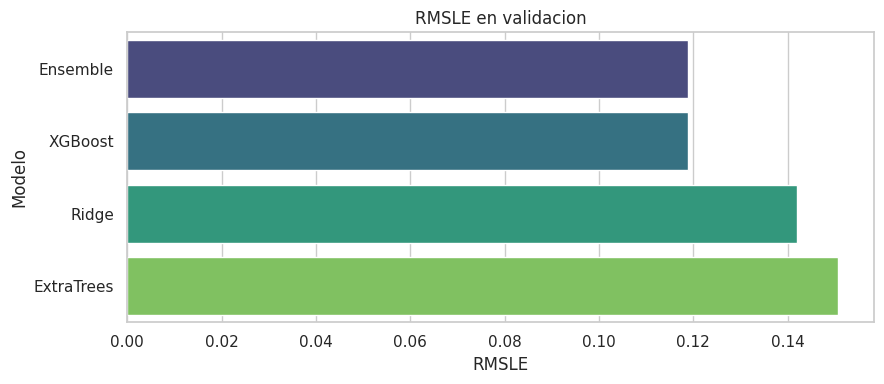

Modelo seleccionado: XGBoost
Criterio: menor RMSLE; en empate técnico, XGBoost.
Resultados finales en test


,Metrica,Valor
0,MAE_USD,16205.483751
1,RMSE_USD,28249.160125
2,RMSLE,0.143691
3,Sesgo_USD,-869.151809


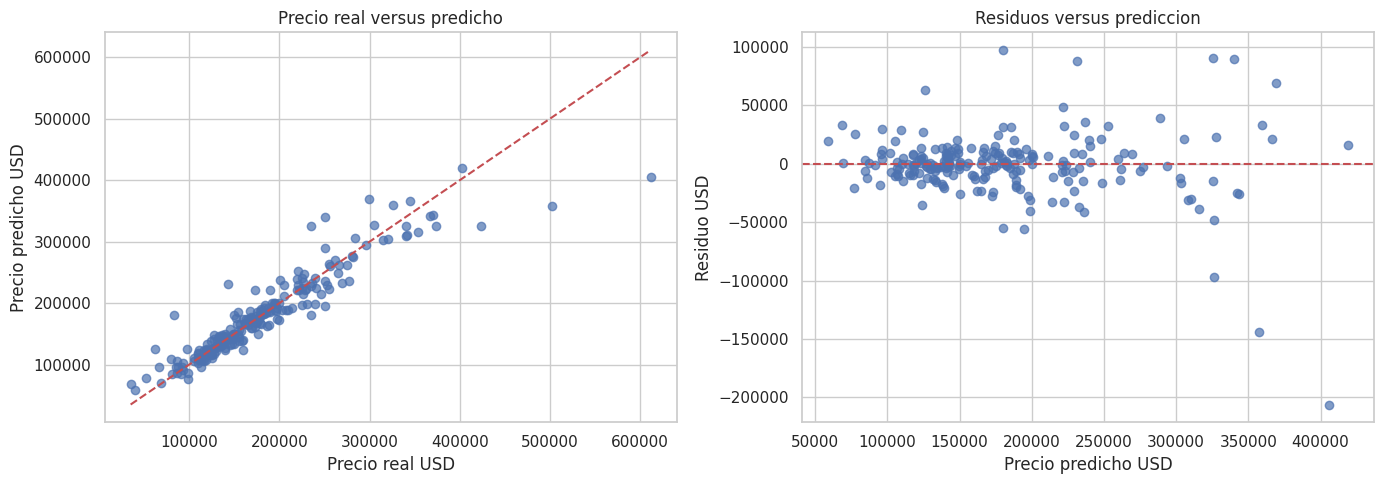

Top 15 features de XGBoost


,Feature,Importancia
2,num__OverallQual,0.124934
34,num__TotalSF,0.101582
39,num__HasFireplace,0.066850
159,cat__ExterQual_TA,0.057161
214,cat__KitchenQual_TA,0.036940
24,num__GarageCars,0.034365
35,num__TotalBath,0.031028
20,num__KitchenAbvGr,0.026755
169,cat__BsmtQual_Ex,0.024572
60,cat__MSZoning_RM,0.023987


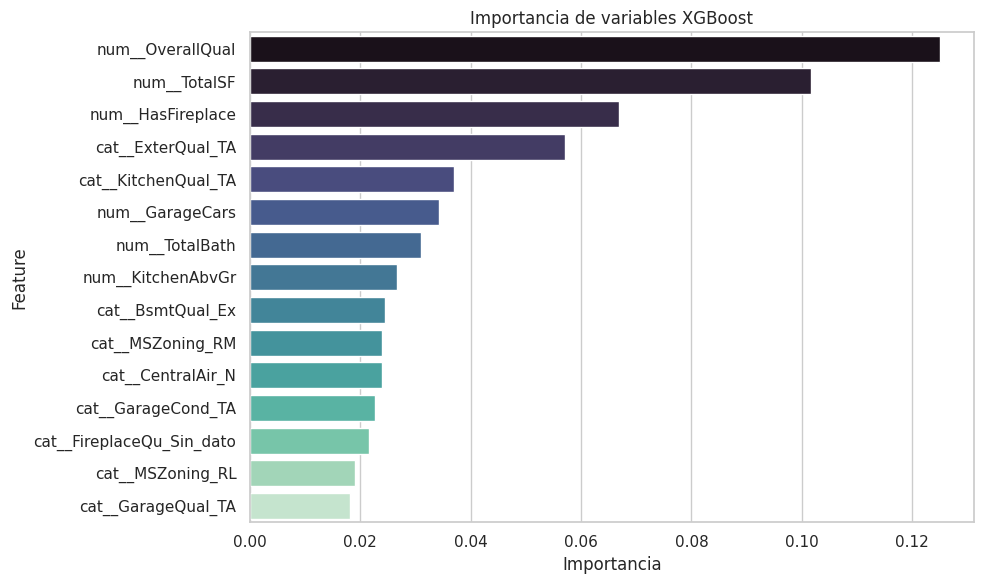

RESUMEN EJECUTIVO
Modelo: XGBoost
RMSLE test: 0.14369
MAE test USD: 16205.48
RMSE test USD: 28249.16


In [4]:
# PUNTOS 4 Y 5: MODELOS OPTIMIZADOS
# Ejecutar despues del punto 3. (Se asume que la preparación de datos del punto 3 ya ha sido ejecutada)
# Usa solamente X_train_ready, X_valid_ready y X_test_ready. (Variables preparadas por el pipeline anterior)

# Importación de librerías necesarias para el desarrollo y evaluación de modelos.
import numpy as np # Para operaciones numéricas, especialmente con arrays.
import pandas as pd # Para manipulación y análisis de datos en DataFrames.
import matplotlib.pyplot as plt # Para la creación de gráficos estáticos.
import seaborn as sns # Para visualizaciones estadísticas atractivas, construido sobre matplotlib.

from scipy import sparse # Para trabajar con matrices dispersas, que son eficientes en memoria para datos con muchos ceros.
from sklearn.ensemble import ExtraTreesRegressor # Un modelo de ensamble tipo 'Random Forest' con árboles extra.
from sklearn.linear_model import Ridge # Un modelo de regresión lineal con regularización L2 (Ridge Regression).
from sklearn.metrics import mean_absolute_error # Métrica para evaluar la magnitud promedio de los errores.
from sklearn.metrics import root_mean_squared_error # Métrica para evaluar el error cuadrático medio de la regresión.
from sklearn.metrics import root_mean_squared_log_error # Métrica para evaluar el error cuadrático medio logarítmico, útil para precios.
from sklearn.model_selection import ParameterGrid # Herramienta para generar combinaciones de parámetros para búsqueda de hiperparámetros.
from xgboost import XGBRegressor # Implementación optimizada de Gradient Boosting, muy potente para problemas de regresión.

sns.set_theme(style='whitegrid') # Establece el tema de los gráficos de Seaborn.
SEED = 42 # Semilla para asegurar la reproducibilidad de resultados aleatorios.
rng = np.random.default_rng(SEED) # Generador de números aleatorios con la semilla especificada.

# Lista de variables que deben estar definidas en el entorno global para que este script funcione.
required = [
    'X_train_ready',
    'X_valid_ready',
    'X_test_ready',
    'y_train',
    'y_valid',
    'y_test',
    'y_usd_test'
]

# Verifica que todas las variables requeridas existan, de lo contrario, lanza un error.
for item in required:
    assert item in globals()

# Función auxiliar para convertir una matriz (posiblemente dispersa) a un array denso de NumPy.
def dense(matrix):
    if sparse.issparse(matrix): # Si la matriz es dispersa, la convierte a densa.
        return matrix.toarray()
    return np.asarray(matrix) # Si ya es densa, la convierte a array de NumPy.

# Función auxiliar para revertir la transformación log(1+x) aplicada a la variable objetivo.
# Se utiliza np.expm1 para deshacer log1p y np.maximum para asegurar que los precios no sean negativos.
def restore(values):
    return np.maximum(np.expm1(values), 0)

# Función para calcular las métricas de evaluación (MAE, RMSE, RMSLE y sesgo) en la escala original (USD).
def score(y_true, y_pred):
    actual = restore(y_true) # Restaura los valores reales a la escala original.
    predicted = restore(y_pred) # Restaura los valores predichos a la escala original.
    mae = mean_absolute_error(actual, predicted) # Calcula el Error Absoluto Medio.
    rmse = root_mean_squared_error(actual, predicted) # Calcula el Error Cuadrático Medio de la Raíz.
    rmsle = root_mean_squared_log_error(actual, predicted) # Calcula el Error Cuadrático Medio Logarítmico de la Raíz.
    bias = np.mean(predicted - actual) # Calcula el sesgo promedio (diferencia entre predicho y real).
    return mae, rmse, rmsle, bias # Retorna todas las métricas calculadas.

# Convierte los conjuntos de datos preprocesados (X) a formato denso y las variables objetivo (y) a arrays de NumPy.
Xtr = dense(X_train_ready) # Conjunto de entrenamiento de características.
Xva = dense(X_valid_ready) # Conjunto de validación de características.
Xte = dense(X_test_ready) # Conjunto de prueba de características.
ytr = np.asarray(y_train) # Variable objetivo de entrenamiento (transformada log1p).
yva = np.asarray(y_valid) # Variable objetivo de validación (transformada log1p).
yte = np.asarray(y_test) # Variable objetivo de prueba (transformada log1p).
yte_usd = np.asarray(y_usd_test) # Variable objetivo de prueba (escala USD original).

# Verificaciones de consistencia de las dimensiones de las características.
assert Xtr.shape[1] == Xva.shape[1] # Asegura que entrenamiento y validación tengan el mismo número de características.
assert Xtr.shape[1] == Xte.shape[1] # Asegura que entrenamiento y prueba tengan el mismo número de características.

print('Features preparados:', Xtr.shape[1]) # Imprime el número total de características.
print('Train, validacion, test:', Xtr.shape[0], Xva.shape[0], Xte.shape[0]) # Imprime el número de filas en cada conjunto.
print('Metrica primaria: RMSLE') # Indica la métrica principal de evaluación.

# ---------------------------------------------------------
# MODELOS COMPLEMENTARIOS (Ridge y ExtraTrees)
# Se inicializan y entrenan dos modelos base para ser utilizados individualmente o en un ensamble.
# ---------------------------------------------------------
# Inicializa el modelo Ridge con un valor de regularización alfa y un solucionador específico.
ridge = Ridge(alpha=20.0, solver='lsqr')
# Inicializa el modelo ExtraTreesRegressor con un número de estimadores, proporción de características, etc.
extra = ExtraTreesRegressor(
    n_estimators=1000,
    max_features=0.85,
    min_samples_leaf=1,
    random_state=SEED,
    n_jobs=-1 # Utiliza todos los núcleos de la CPU disponibles.
)

ridge.fit(Xtr, ytr) # Entrena el modelo Ridge con los datos de entrenamiento.
extra.fit(Xtr, ytr) # Entrena el modelo ExtraTrees con los datos de entrenamiento.
ridge_va = ridge.predict(Xva) # Realiza predicciones con Ridge en el conjunto de validación.
extra_va = extra.predict(Xva) # Realiza predicciones con ExtraTrees en el conjunto de validación.

# ---------------------------------------------------------
# BUSQUEDA DE XGBOOST SOBRE VALIDACION
# Se realiza una búsqueda de hiperparámetros aleatoria (Random Search) para optimizar un modelo XGBoost.
# ---------------------------------------------------------
# Define la cuadrícula de parámetros a explorar para XGBoost.
param_grid = {
    'learning_rate': [0.02, 0.03, 0.05],
    'max_depth': [2, 3, 4],
    'min_child_weight': [1, 3, 5],
    'subsample': [0.75, 0.90],
    'colsample_bytree': [0.70, 0.90],
    'reg_lambda': [1.0, 5.0],
    'reg_alpha': [0.0, 0.05]
}

all_params = list(ParameterGrid(param_grid)) # Genera todas las combinaciones posibles de parámetros.
# Selecciona aleatoriamente 24 combinaciones de parámetros para probar, sin reemplazo.
positions = rng.choice(len(all_params), size=24, replace=False)
trials = [] # Lista para almacenar los resultados de cada prueba de hiperparámetros.
best_xgb = None # Variable para almacenar el mejor modelo XGBoost encontrado.
best_rmsle = np.inf # Variable para rastrear el mejor RMSLE obtenido.

# Itera sobre las posiciones seleccionadas para entrenar y evaluar modelos XGBoost.
for position in positions:
    p = all_params[int(position)] # Obtiene el diccionario de parámetros para la posición actual.
    xgb = XGBRegressor( # Inicializa el modelo XGBoost con los parámetros actuales.
        n_estimators=3000, # Número máximo de árboles, con early stopping para evitar sobreajuste.
        learning_rate=p['learning_rate'],
        max_depth=p['max_depth'],
        min_child_weight=p['min_child_weight'],
        subsample=p['subsample'],
        colsample_bytree=p['colsample_bytree'],
        reg_lambda=p['reg_lambda'],
        reg_alpha=p['reg_alpha'],
        objective='reg:squarederror', # Función objetivo para regresión.
        eval_metric='rmse', # Métrica de evaluación para el early stopping.
        early_stopping_rounds=100, # Detiene el entrenamiento si el rendimiento no mejora en 100 rondas.
        tree_method='hist', # Método de construcción de árboles más rápido.
        random_state=SEED,
        n_jobs=-1
    )
    # Entrena el modelo XGBoost, evaluando su rendimiento en el conjunto de validación.
    xgb.fit(Xtr, ytr, eval_set=[(Xva, yva)], verbose=False)
    prediction = xgb.predict(Xva) # Realiza predicciones en el conjunto de validación.
    mae, rmse, rmsle, bias = score(yva, prediction) # Calcula las métricas de evaluación.
    trials.append([ # Almacena los resultados de la prueba actual.
        p['learning_rate'],
        p['max_depth'],
        p['min_child_weight'],
        p['subsample'],
        p['colsample_bytree'],
        p['reg_lambda'],
        p['reg_alpha'],
        mae,
        rmse,
        rmsle,
        bias
    ])
    if rmsle < best_rmsle: # Si el RMSLE actual es mejor que el mejor registrado, actualiza.
        best_rmsle = rmsle
        best_xgb = xgb # Guarda el modelo como el mejor XGBoost.

# Define los nombres de las columnas para el DataFrame de resultados de las pruebas.
trial_columns = [
    'learning_rate',
    'max_depth',
    'min_child_weight',
    'subsample',
    'colsample_bytree',
    'reg_lambda',
    'reg_alpha',
    'MAE_USD',
    'RMSE_USD',
    'RMSLE',
    'Sesgo_USD'
]

trials = pd.DataFrame(trials, columns=trial_columns) # Crea un DataFrame con los resultados de todas las pruebas.
trials = trials.sort_values('RMSLE').reset_index(drop=True) # Ordena los resultados por RMSLE ascendente.
print('Top 10 configuraciones XGBoost') # Imprime las 10 mejores configuraciones de XGBoost.
display(trials.head(10))

xgb_va = best_xgb.predict(Xva) # Realiza predicciones con el mejor modelo XGBoost en validación.

# ---------------------------------------------------------
# ENSEMBLE: Pesos elegidos solo con validación
# Combina las predicciones de los modelos Ridge, ExtraTrees y XGBoost mediante un weighted average.
# ---------------------------------------------------------
weights = np.arange(0.0, 1.01, 0.05) # Genera un rango de pesos de 0.0 a 1.0 con pasos de 0.05.
best_weights = [1.0, 0.0, 0.0] # Inicializa los mejores pesos (XGBoost, ExtraTrees, Ridge).
best_blend = None # Variable para almacenar la mejor mezcla de predicciones.
best_blend_rmsle = np.inf # Variable para rastrear el mejor RMSLE del ensamble.

# Itera sobre todas las combinaciones posibles de pesos para el ensamble.
for wxgb in weights: # Peso para XGBoost.
    for wextra in weights: # Peso para ExtraTrees.
        wridge = 1.0 - wxgb - wextra # Calcula el peso para Ridge (la suma de los 3 debe ser 1).
        if wridge < 0: # Si el peso de Ridge es negativo, esta combinación no es válida.
            continue
        # Calcula la predicción del ensamble.
        blend = wxgb * xgb_va + wextra * extra_va + wridge * ridge_va
        mae, rmse, rmsle, bias = score(yva, blend) # Evalúa el rendimiento del ensamble.
        if rmsle < best_blend_rmsle: # Si el RMSLE actual es mejor, actualiza los mejores pesos y el ensamble.
            best_blend_rmsle = rmsle
            best_weights = [wxgb, wextra, wridge]
            best_blend = blend

# ---------------------------------------------------------
# COMPARAR MODELOS EN VALIDACION
# Evalúa el rendimiento de cada modelo individual y del ensamble en el conjunto de validación.
# ---------------------------------------------------------
r_mae, r_rmse, r_rmsle, r_bias = score(yva, ridge_va) # Métricas para Ridge.
e_mae, e_rmse, e_rmsle, e_bias = score(yva, extra_va) # Métricas para ExtraTrees.
x_mae, x_rmse, x_rmsle, x_bias = score(yva, xgb_va) # Métricas para XGBoost.
b_mae, b_rmse, b_rmsle, b_bias = score(yva, best_blend) # Métricas para el mejor ensamble.

# Crea un DataFrame para comparar los resultados de los modelos.
results = pd.DataFrame([
    ['Ridge', r_mae, r_rmse, r_rmsle, r_bias],
    ['ExtraTrees', e_mae, e_rmse, e_rmsle, e_bias],
    ['XGBoost', x_mae, x_rmse, x_rmsle, x_bias],
    ['Ensemble', b_mae, b_rmse, b_rmsle, b_bias]
], columns=['Modelo', 'MAE_USD', 'RMSE_USD', 'RMSLE', 'Sesgo_USD'])

results = results.sort_values('RMSLE').reset_index(drop=True) # Ordena los resultados por RMSLE.
display(results) # Muestra la tabla comparativa de resultados.

# Genera un gráfico de barras para visualizar el RMSLE de cada modelo en validación.
plt.figure(figsize=(9, 4))
sns.barplot(data=results, x='RMSLE', y='Modelo', palette='viridis')
plt.title('RMSLE en validacion') # Título del gráfico: Muestra el RMSLE (Error Cuadrático Medio Logarítmico) para cada modelo en el conjunto de validación.
plt.tight_layout()
plt.show()

# Explicación del gráfico 'RMSLE en validacion':
# - Este gráfico de barras compara el rendimiento de los modelos individuales (Ridge, ExtraTrees, XGBoost) y el ensamble en el conjunto de validación.
# - El eje Y muestra el nombre del modelo.
# - El eje X muestra el valor de la métrica RMSLE. Un valor más bajo de RMSLE indica un mejor rendimiento predictivo del modelo, ya que esta métrica penaliza más los errores grandes en las predicciones de precios más bajos, siendo muy adecuada para variables objetivo con distribuciones sesgadas como los precios de venta.
# - La barra más corta representa el modelo o ensamble con el mejor rendimiento en validación según esta métrica.

# ---------------------------------------------------------
# Politica de desempate y selección final del modelo
# Se define un criterio para seleccionar el modelo final basado en el RMSLE.
# ---------------------------------------------------------
TOLERANCIA_RMSLE = 0.000001 # Tolerancia para considerar si dos RMSLE son 'prácticamente iguales'.

# Obtiene el RMSLE del modelo XGBoost.
rmsle_xgb = results.loc[
    results['Modelo'] == 'XGBoost',
    'RMSLE'
].iloc[0]

# Obtiene el RMSLE del modelo Ensemble.
rmsle_ensemble = results.loc[
    results['Modelo'] == 'Ensemble',
    'RMSLE'
].iloc[0]

# Aplica la política de desempate: si son casi iguales, prefiere XGBoost por simplicidad.
if abs(rmsle_xgb - rmsle_ensemble) <= TOLERANCIA_RMSLE:
    selected = 'XGBoost'
else:
    selected = results.loc[0, 'Modelo'] # Selecciona el modelo con el RMSLE más bajo.

print('Modelo seleccionado:', selected) # Imprime el nombre del modelo seleccionado.
print('Criterio: menor RMSLE; en empate técnico, XGBoost.') # Explica el criterio de selección.

# ---------------------------------------------------------
# EVALUACION FINAL EN TEST
# Se evalúa el rendimiento del modelo seleccionado en el conjunto de prueba (test).
# ---------------------------------------------------------
ridge_te = ridge.predict(Xte) # Predicciones de Ridge en test.
extra_te = extra.predict(Xte) # Predicciones de ExtraTrees en test.
xgb_te = best_xgb.predict(Xte) # Predicciones del mejor XGBoost en test.
# Predicciones del ensamble en test, usando los pesos óptimos encontrados en validación.
blend_te = (
    best_weights[0] * xgb_te
    + best_weights[1] * extra_te
    + best_weights[2] * ridge_te
)

# Asigna las predicciones del modelo seleccionado para la evaluación final.
if selected == 'Ridge':
    test_pred = ridge_te
elif selected == 'ExtraTrees':
    test_pred = extra_te
else:
    test_pred = xgb_te

# Calcula las métricas finales en el conjunto de prueba.
test_mae, test_rmse, test_rmsle, test_bias = score(yte, test_pred)
test_usd_pred = restore(test_pred) # Restaura las predicciones a la escala USD.

# Presenta los resultados finales en un DataFrame.
final_results = pd.DataFrame([
    ['MAE_USD', test_mae],
    ['RMSE_USD', test_rmse],
    ['RMSLE', test_rmsle],
    ['Sesgo_USD', test_bias]
], columns=['Metrica', 'Valor'])

print('Resultados finales en test') # Mensaje de los resultados finales.
display(final_results) # Muestra el DataFrame de resultados finales.

# ---------------------------------------------------------
# GRAFICOS DE EVALUACION
# Visualiza las predicciones y los residuos del modelo seleccionado en el conjunto de prueba.
# ---------------------------------------------------------
residuals = test_usd_pred - yte_usd # Calcula los residuos (diferencia entre predicho y real).

fig, axes = plt.subplots(1, 2, figsize=(14, 5)) # Crea una figura con dos subplots.
# Gráfico de dispersión de precios reales vs. predichos.
axes[0].scatter(yte_usd, test_usd_pred, alpha=0.70)
low = min(yte_usd.min(), test_usd_pred.min()) # Encuentra el valor mínimo para la línea de referencia.
high = max(yte_usd.max(), test_usd_pred.max()) # Encuentra el valor máximo para la línea de referencia.
axes[0].plot([low, high], [low, high], 'r--') # Dibuja una línea de referencia y=x.
axes[0].set_title('Precio real versus predicho') # Título del gráfico: Compara el precio real de las casas con el precio predicho por el modelo en el conjunto de prueba.
axes[0].set_xlabel('Precio real USD')
axes[0].set_ylabel('Precio predicho USD')

# Gráfico de dispersión de residuos vs. predicciones.
axes[1].scatter(test_usd_pred, residuals, alpha=0.70)
axes[1].axhline(0, color='r', linestyle='--') # Dibuja una línea horizontal en cero para los residuos.
axes[1].set_title('Residuos versus prediccion') # Título del gráfico: Muestra la distribución de los errores de predicción (residuos) en función de los precios predichos.
axes[1].set_xlabel('Precio predicho USD')
axes[1].set_ylabel('Residuo USD')
plt.tight_layout()
plt.show()

# Explicación de las gráficas 'Precio real versus predicho' y 'Residuos versus prediccion':
# - 'Precio real versus predicho': Cada punto representa una casa del conjunto de prueba. El eje X es el precio real en USD y el eje Y es el precio predicho. La línea roja discontinua representa predicciones perfectas (donde el precio predicho es igual al real). Cuanto más cerca estén los puntos de esta línea, mejor es el rendimiento del modelo.
# - 'Residuos versus prediccion': Cada punto representa el residuo (error = precio real - precio predicho) para una casa, trazado contra el precio predicho en el eje X. La línea roja discontinua en Y=0 indica un error de cero. Idealmente, los puntos deben distribuirse aleatoriamente alrededor de la línea de cero, sin mostrar patrones (como una forma de embudo o una curvatura), lo que indicaría que el modelo no tiene sesgos sistemáticos en sus predicciones.

# ---------------------------------------------------------
# IMPORTANCIA POR PERMUTACION EN VALIDACION (Importancia de Características)
# Calcula y visualiza la importancia de las características del mejor modelo XGBoost.
# ---------------------------------------------------------
# Intenta obtener los nombres de las características finales. Si no están definidos, usa un formato genérico.
if 'feature_names_final' in globals():
    feature_names = list(feature_names_final)
elif 'final_names' in globals():
    feature_names = list(final_names)
else:
    feature_names = ['feature_' + str(i) for i in range(Xtr.shape[1])]

importance = best_xgb.feature_importances_ # Obtiene la importancia de las características del mejor XGBoost.
importance_table = pd.DataFrame({ # Crea un DataFrame con las características y su importancia.
    'Feature': feature_names,
    'Importancia': importance
})
importance_table = importance_table.sort_values(
    'Importancia',
    ascending=False
) # Ordena la tabla por importancia de forma descendente.

top_features = importance_table.head(15) # Selecciona las 15 características más importantes.
print('Top 15 features de XGBoost') # Imprime las características principales.
display(top_features) # Muestra el DataFrame de las top 15 características.

# Genera un gráfico de barras para visualizar la importancia de las top 15 características.
plt.figure(figsize=(10, 6))
sns.barplot(data=top_features, x='Importancia', y='Feature', palette='mako')
plt.title('Importancia de variables XGBoost') # Título del gráfico: Muestra las 15 características más influyentes para el modelo XGBoost.
plt.tight_layout()
plt.show()

# Explicación del gráfico 'Importancia de variables XGBoost':
# - Este gráfico de barras muestra la importancia relativa de las 15 características más influyentes que el modelo XGBoost utilizó para realizar sus predicciones.
# - El eje Y muestra el nombre de cada característica.
# - El eje X indica la 'Importancia' de cada característica, calculada por el modelo (generalmente basada en cuántas veces una característica es usada para dividir un nodo en los árboles o cuánto reduce el error). Una barra más larga significa que la característica tuvo un mayor impacto en las predicciones del modelo. Esto ayuda a comprender qué atributos de las viviendas son los más relevantes para determinar su precio de venta.

# ---------------------------------------------------------
# RESUMEN EJECUTIVO
# Presenta un resumen final del modelo seleccionado y sus métricas clave en el conjunto de prueba.
# ---------------------------------------------------------
print('RESUMEN EJECUTIVO')
print('Modelo:', selected)
print('RMSLE test:', round(test_rmsle, 5))
print('MAE test USD:', round(test_mae, 2))
print('RMSE test USD:', round(test_rmse, 2))

# Objetivo del código: Este script se encarga de entrenar y optimizar múltiples modelos de regresión (Ridge, ExtraTrees, XGBoost),
# realizar una búsqueda de hiperparámetros para XGBoost, explorar diferentes combinaciones de ensamble, evaluar el rendimiento
# de los modelos en el conjunto de validación para seleccionar el mejor, y finalmente, evaluar el modelo elegido en un
# conjunto de prueba independiente para estimar su rendimiento en datos no vistos. Además, visualiza las predicciones,
# residuos y la importancia de las características para una mejor comprensión del modelo.
